In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def getCSV(name):
    dfl = pd.read_csv(name)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\BirthplaceCork.csv') 
print(df)
print(list(set(df['Location'])))

                                 Statistic Label  Census Year  \
0      Usually resident population by birthplace         2022   
1      Usually resident population by birthplace         2022   
2      Usually resident population by birthplace         2022   
3      Usually resident population by birthplace         2022   
4      Usually resident population by birthplace         2022   
...                                          ...          ...   
2667  Usually resident population by citizenship         2022   
2668  Usually resident population by citizenship         2022   
2669  Usually resident population by citizenship         2022   
2670  Usually resident population by citizenship         2022   
2671  Usually resident population by citizenship         2022   

            CSO Local Electoral Areas 2022  \
0     Borris-In-Ossory-Mountmellick, Laois   
1     Borris-In-Ossory-Mountmellick, Laois   
2     Borris-In-Ossory-Mountmellick, Laois   
3     Borris-In-Ossory-Mountmellick

In [42]:
county = 'Waterford'
label = 'Usually resident population by birthplace'
#label = 'Usually resident population by citizenship'

filtered_df = df[df['CSO Local Electoral Areas 2022'].str.contains(county)]
filtered_df = filtered_df[filtered_df["Statistic Label"]==label]
filtered_df = filtered_df[filtered_df['CSO Local Electoral Areas 2022']!="Ireland"]
filtered_df = filtered_df[filtered_df['Location']!="Total"]
filtered_df['CSO Local Electoral Areas 2022'] = filtered_df['CSO Local Electoral Areas 2022'].apply(lambda x: x.split(",")[0])
filtered_df['Location'] = filtered_df['Location'].apply(lambda x: "Other EU" if x=="Other EU272020 (Exec Ireland & Poland)" else x)
print(filtered_df)

                               Statistic Label  Census Year  \
464  Usually resident population by birthplace         2022   
465  Usually resident population by birthplace         2022   
466  Usually resident population by birthplace         2022   
467  Usually resident population by birthplace         2022   
468  Usually resident population by birthplace         2022   
469  Usually resident population by birthplace         2022   
470  Usually resident population by birthplace         2022   
472  Usually resident population by birthplace         2022   
473  Usually resident population by birthplace         2022   
474  Usually resident population by birthplace         2022   
475  Usually resident population by birthplace         2022   
476  Usually resident population by birthplace         2022   
477  Usually resident population by birthplace         2022   
478  Usually resident population by birthplace         2022   
480  Usually resident population by birthplace         

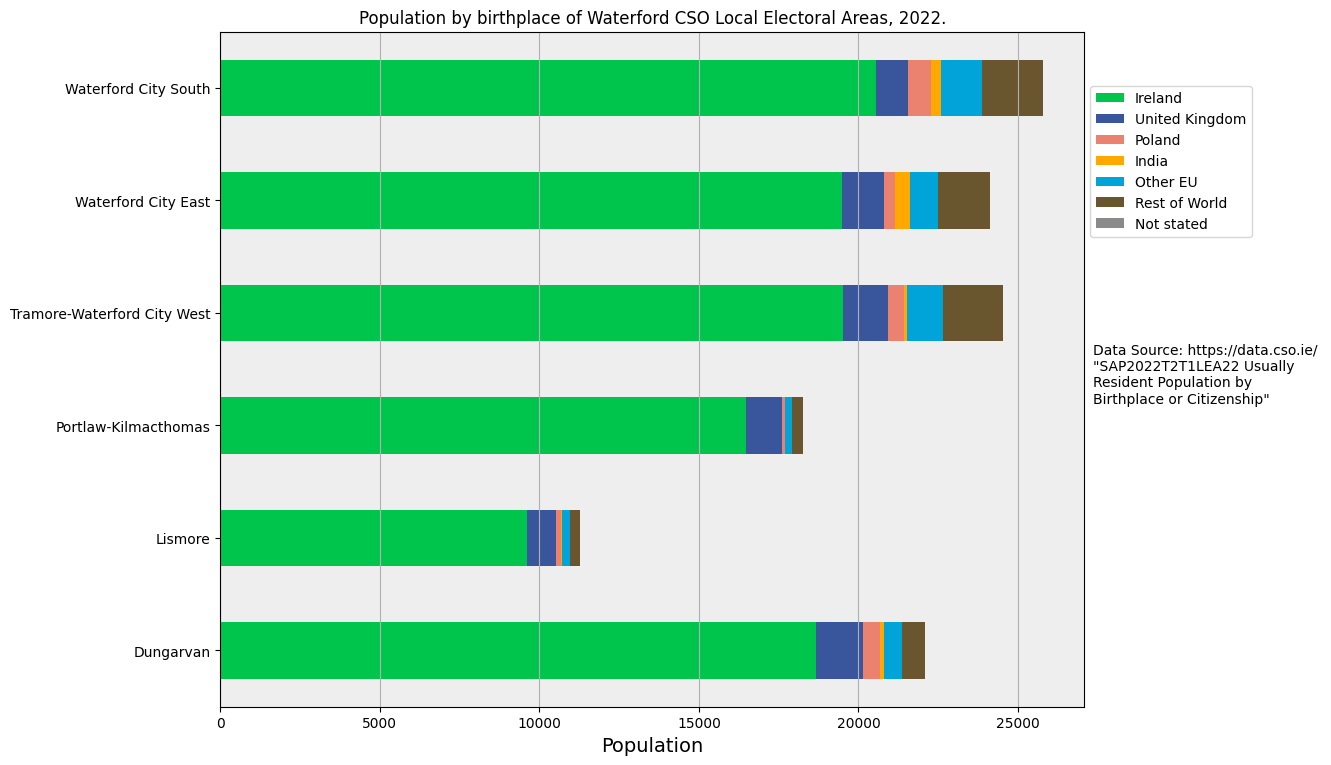

In [43]:
fig, ax = plt.subplots(1,1,figsize=(12,8))

pivot_df = filtered_df.pivot_table(index='CSO Local Electoral Areas 2022', columns='Location', values='VALUE', aggfunc='sum', fill_value=0)

desired_order = [
    "Ireland",
    "United Kingdom",
    "Poland",
    "India",
    "Other EU",
    "Rest of World",
    "Not stated"
]

pivot_df = pivot_df.reindex(columns=desired_order)

colors = ["#00c54d","#39569d", "#eA826f", "#ffa800", "#00a4d8", "#69562F", "#8a8a8a"]
pivot_df.plot(kind='barh', stacked=True, figsize=(12, 9), ax=ax, color=colors, width= .5)

ax.set_facecolor('#EEEEEE') 
# plt.grid(True)
plt.xlabel('Population', fontsize=14)
plt.ylabel('')
plt.grid(axis='x')
plt.legend(loc='upper left', bbox_to_anchor=(.999, .93))

plt.xticks(rotation=0)
plt.title('Population by '+label.split(" ")[-1]+' of '+county+' CSO Local Electoral Areas, 2022.')

plt.subplots_adjust(left=0.08, right=0.8, top=0.9, bottom=0.15)
plt.text(1.01, +0.45, "Data Source: https://data.cso.ie/ \n\"SAP2022T2T1LEA22 Usually \nResident Population by \nBirthplace or Citizenship\"", ha='left', transform=ax.transAxes)

plt.savefig('Electoral-'+label.split(" ")[-1]+'-'+county+'.png', bbox_inches='tight')

plt.show()

In [39]:
#SAP2022T2T1LEA22-Usually Resident Population by Birthplace or Citizenship